In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,Conv1D,Bidirectional,GRU,LSTM,GlobalMaxPooling1D, Dense, Dropout
import pandas as pd
import numpy as np

Loading X_test,y_test,X_train.y_train values

In [2]:
X_test=np.load("X_test.npy")
y_test=np.load("y_test.npy")

In [3]:
X_train=np.load("X_train_bal.npy")
y_train=np.load("y_train_bal.npy")

In [4]:
embedding_matrix = np.load("embedding_matrix.npy")

BiGru LSTM Model

In [5]:
# parameters
vocab_size = 5000
embedding_dim = 100
max_len = X_train.shape[1]   # use your padded length

# model
model = Sequential()

#  Embedding Layer (Word2Vec)
model.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False   # IMPORTANT (paper uses pretrained embeddings)
))

#  CNN Layer
model.add(Conv1D(
    filters=128,
    kernel_size=5,
    activation='relu'
))

#  BiGRU Layer
model.add(Bidirectional(GRU(
    64,
    return_sequences=True
)))

#  LSTM Layer
model.add(LSTM(
    64,
    return_sequences=True
))

#  Pooling
model.add(GlobalMaxPooling1D())

# Regularization
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))   # binary classification

# compile
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# summary
model.summary()

c:\Users\siddh\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

In [8]:
model.save("BiGruLSTMmodel.keras")

c:\Users\siddh\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


In [9]:
model.compile(
    loss="binary_crossentropy",
    optimizer='adam',
    metrics=['accuracy']
)

Model Training

In [10]:
history=model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 24s 203ms/step - accuracy: 0.9130 - loss: 0.2300 - val_accuracy: 0.3620 - val_loss: 0.9647
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 11s 158ms/step - accuracy: 0.9507 - loss: 0.1119 - val_accuracy: 0.8866 - val_loss: 0.3764
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 20s 149ms/step - accuracy: 0.9770 - loss: 0.0626 - val_accuracy: 0.9191 - val_loss: 0.2548
Epoch 4/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.9768 - loss: 0.0580 - val_accuracy: 0.9216 - val_loss: 0.2444
Epoch 5/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 150ms/step - accuracy: 0.9890 - loss: 0.0375 - val_accuracy: 0.9049 - val_loss: 0.2435
Epoch 6/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 11s 157ms/step - accuracy: 0.9911 - loss: 0.0292 - val_accuracy: 0.9525 - val_loss: 0.1773
Epoch 7/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 21s 158ms/step - accuracy: 0.9941 - loss: 0.0211 - val_accuracy: 0.8849 - val_loss: 0.3581
Epoch 8/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 20s 146ms/step - accuracy: 0.9974 - loss: 0.0137 - val_accu

In [11]:
model.save("trainedModel.keras")

Model Evaluation and Classification Report

In [12]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9508 - loss: 0.2059
Test Loss: 0.20590423047542572
Test Accuracy: 0.9507923126220703


In [30]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.4).astype(int)

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step


In [31]:
from sklearn.metrics import classification_report
report=classification_report(y_test,y_pred)

In [32]:
print(report)

              precision    recall  f1-score   support

           0       0.85      0.92      0.88       231
           1       0.98      0.96      0.97       968

    accuracy                           0.95      1199
   macro avg       0.91      0.94      0.93      1199
weighted avg       0.95      0.95      0.95      1199



In [33]:
from sklearn.metrics import confusion_matrix, roc_auc_score
matrix=confusion_matrix(y_test,y_pred)
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))
print("matrix:",matrix)

ROC-AUC: 0.979629530249365
matrix: [[213  18]
 [ 39 929]]


Visualizations

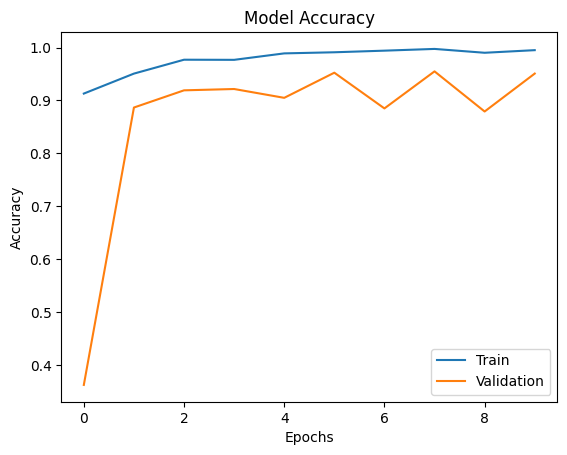

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

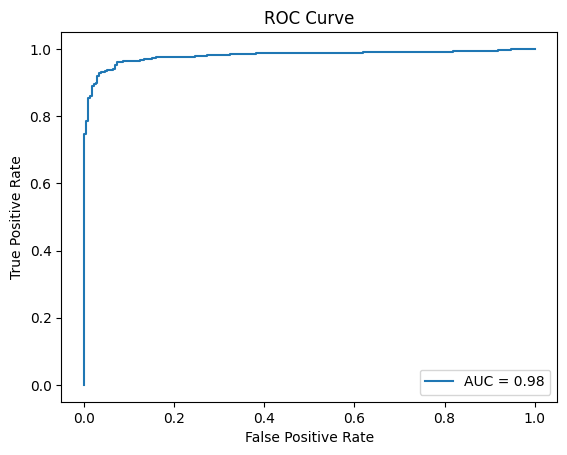

In [37]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

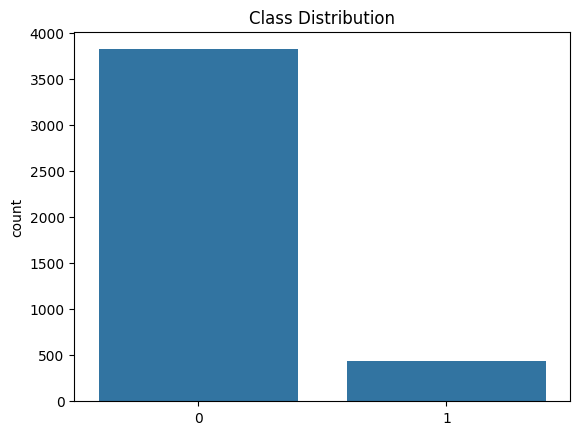

In [38]:
import seaborn as sns

sns.countplot(x=y_train)
plt.title("Class Distribution")
plt.show()